In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Generate sample data - 3 clusters
def generate_data():
    # Cluster 1: centered at (2, 2)
    cluster1 = torch.randn(30, 2) * 0.5 + torch.tensor([2.0, 2.0])
    
    # Cluster 2: centered at (7, 3)
    cluster2 = torch.randn(30, 2) * 0.5 + torch.tensor([7.0, 3.0])
    
    # Cluster 3: centered at (5, 8)
    cluster3 = torch.randn(30, 2) * 0.5 + torch.tensor([5.0, 8.0])
    
    # Combine all clusters
    data = torch.cat([cluster1, cluster2, cluster3], dim=0)
    
    return data

# Generate data
X = generate_data()
print(f"Data shape: {X.shape}")
print(f"First 5 data points:\n{X[:5]}")

Data shape: torch.Size([90, 2])
First 5 data points:
tensor([[2.9635, 2.7436],
        [2.4504, 0.9472],
        [2.3392, 1.3827],
        [1.9785, 1.1977],
        [1.6239, 2.8244]])


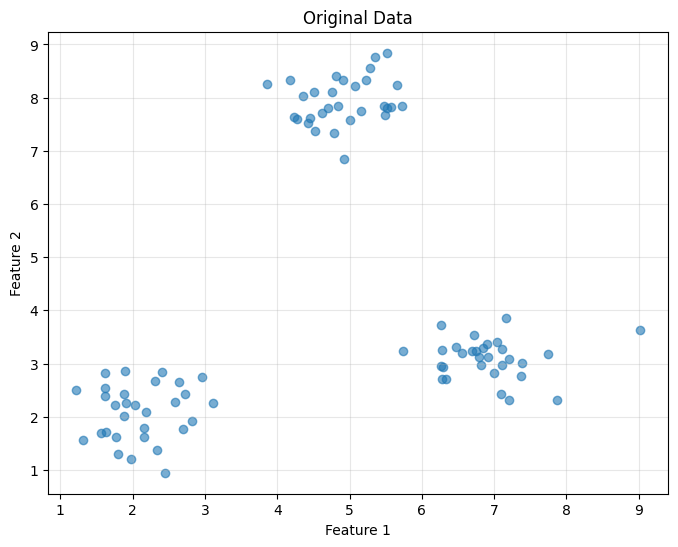

In [3]:
# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
class KMeans:
    def __init__(self, n_clusters=3, max_iters=100, tolerance=1e-4):
        """
        K-Means clustering implementation from scratch
        
        Parameters:
        -----------
        n_clusters : int
            Number of clusters
        max_iters : int
            Maximum number of iterations
        tolerance : float
            Convergence tolerance
        """
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tolerance = tolerance
        self.centroids = None
        self.labels = None
        
    def initialize_centroids(self, X):
        """
        Initialize centroids by randomly selecting K data points
        """
        n_samples = X.shape[0]
        random_indices = torch.randperm(n_samples)[:self.n_clusters]
        self.centroids = X[random_indices].clone()
        
    def compute_distances(self, X):
        """
        Compute Euclidean distance between each point and all centroids
        Returns: (n_samples, n_clusters) distance matrix
        """
        # Expand dimensions for broadcasting
        # X: (n_samples, n_features) -> (n_samples, 1, n_features)
        # centroids: (n_clusters, n_features) -> (1, n_clusters, n_features)
        X_expanded = X.unsqueeze(1)  # (n_samples, 1, n_features)
        centroids_expanded = self.centroids.unsqueeze(0)  # (1, n_clusters, n_features)
        
        # Compute squared Euclidean distances
        distances = torch.sum((X_expanded - centroids_expanded) ** 2, dim=2)
        distances = torch.sqrt(distances)
        
        return distances
    
    def assign_clusters(self, X):
        """
        Assign each point to the nearest centroid
        """
        distances = self.compute_distances(X)
        self.labels = torch.argmin(distances, dim=1)
        return self.labels
    
    def update_centroids(self, X):
        """
        Update centroids as the mean of points assigned to each cluster
        """
        new_centroids = torch.zeros_like(self.centroids)
        
        for k in range(self.n_clusters):
            # Get all points assigned to cluster k
            cluster_points = X[self.labels == k]
            
            if len(cluster_points) > 0:
                # Compute mean of cluster points
                new_centroids[k] = cluster_points.mean(dim=0)
            else:
                # If no points assigned, keep the old centroid
                new_centroids[k] = self.centroids[k]
        
        return new_centroids
    
    def fit(self, X):
        """
        Fit K-Means to data
        """
        # Initialize centroids
        self.initialize_centroids(X)
        
        print(f"Initial centroids:\n{self.centroids}\n")
        
        for iteration in range(self.max_iters):
            # Store old centroids
            old_centroids = self.centroids.clone()
            
            # Step 1: Assign clusters
            self.assign_clusters(X)
            
            # Step 2: Update centroids
            self.centroids = self.update_centroids(X)
            
            # Check convergence
            centroid_shift = torch.sum((self.centroids - old_centroids) ** 2)
            
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Centroid shift = {centroid_shift:.6f}")
            
            if centroid_shift < self.tolerance:
                print(f"\nConverged at iteration {iteration}")
                break
        
        print(f"\nFinal centroids:\n{self.centroids}")
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for new data
        """
        distances = self.compute_distances(X)
        return torch.argmin(distances, dim=1)
    
    def compute_inertia(self, X):
        """
        Compute inertia (sum of squared distances to nearest centroid)
        """
        distances = self.compute_distances(X)
        min_distances = torch.min(distances, dim=1)[0]
        inertia = torch.sum(min_distances ** 2)
        return inertia.item()

In [5]:
# Create and train K-Means model
kmeans = KMeans(n_clusters=3, max_iters=100, tolerance=1e-4)
kmeans.fit(X)

Initial centroids:
tensor([[4.2337, 7.6374],
        [1.8883, 2.8587],
        [6.2879, 2.9418]])

Iteration 0: Centroid shift = 1.589396

Converged at iteration 1

Final centroids:
tensor([[4.9080, 7.9368],
        [2.1003, 2.0909],
        [6.9087, 3.1009]])


In [6]:
# Get predictions
labels = kmeans.predict(X)
print(f"\nCluster assignments: {labels}")
print(f"\nCluster counts:")
for i in range(kmeans.n_clusters):
    count = torch.sum(labels == i).item()
    print(f"  Cluster {i}: {count} points")


Cluster assignments: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Cluster counts:
  Cluster 0: 30 points
  Cluster 1: 30 points
  Cluster 2: 30 points


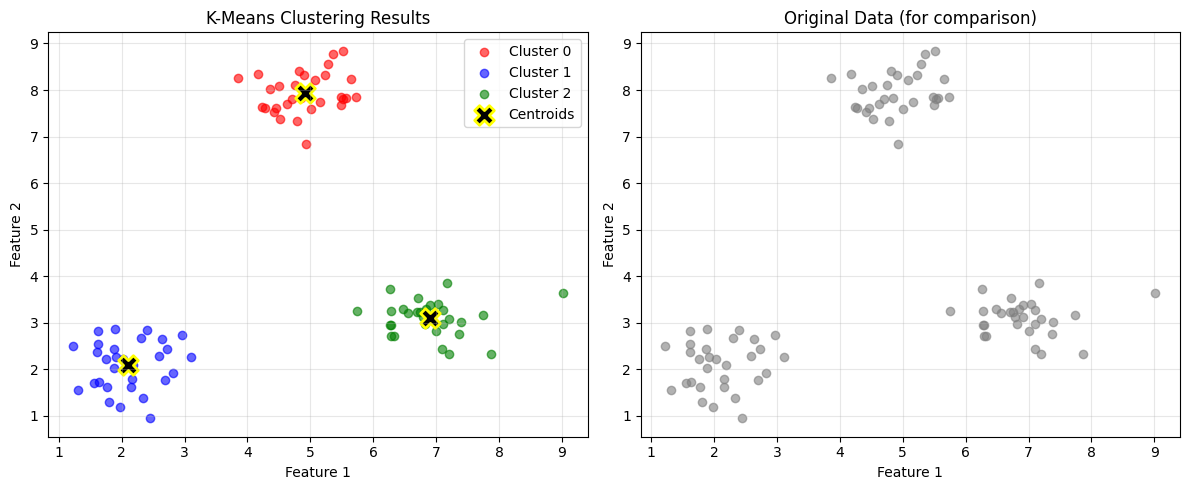

In [7]:
# Visualize clustering results
plt.figure(figsize=(12, 5))

# Plot 1: Data points colored by cluster
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for i in range(kmeans.n_clusters):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.6)

# Plot centroids
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
            c='black', marker='X', s=200, edgecolors='yellow', linewidths=2,
            label='Centroids')
plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Original data for comparison
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, c='gray')
plt.title('Original Data (for comparison)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
inertia = kmeans.compute_inertia(X)
print(f"Inertia (WCSS): {inertia:.4f}")

Inertia (WCSS): 43.0997


In [9]:
# Simple example with 4 points and 2 clusters
print("=" * 60)
print("SIMPLE EXAMPLE: 4 Points, 2 Clusters")
print("=" * 60)

# Create 4 simple data points
simple_data = torch.tensor([
    [1.0, 1.0],
    [1.5, 2.0],
    [5.0, 8.0],
    [8.0, 8.0]
])

print(f"\nData points:\n{simple_data}\n")

# Apply K-Means with 2 clusters
kmeans_simple = KMeans(n_clusters=2, max_iters=50, tolerance=1e-6)
kmeans_simple.fit(simple_data)

# Get cluster assignments
simple_labels = kmeans_simple.predict(simple_data)
print(f"\nFinal cluster assignments: {simple_labels}")

SIMPLE EXAMPLE: 4 Points, 2 Clusters

Data points:
tensor([[1.0000, 1.0000],
        [1.5000, 2.0000],
        [5.0000, 8.0000],
        [8.0000, 8.0000]])

Initial centroids:
tensor([[1., 1.],
        [5., 8.]])

Iteration 0: Centroid shift = 2.562500

Converged at iteration 1

Final centroids:
tensor([[1.2500, 1.5000],
        [6.5000, 8.0000]])

Final cluster assignments: tensor([0, 0, 1, 1])


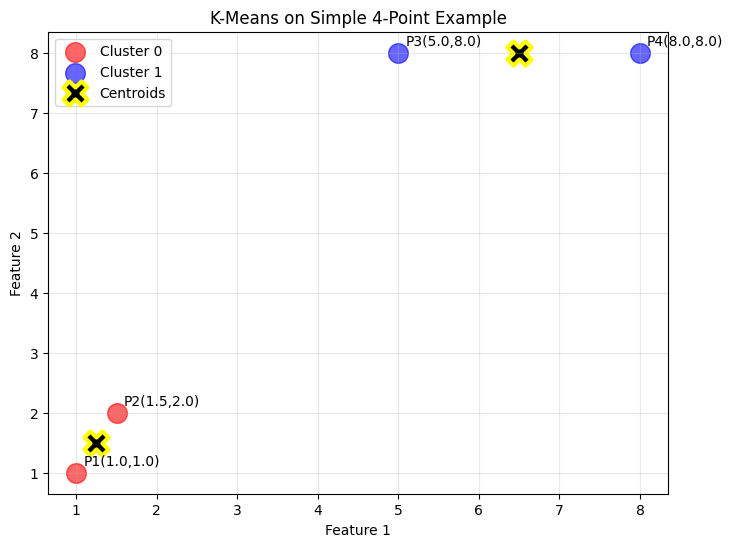

In [10]:
# Visualize simple example
plt.figure(figsize=(8, 6))

colors_simple = ['red', 'blue']
for i in range(2):
    cluster_points = simple_data[simple_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors_simple[i], s=200, label=f'Cluster {i}', alpha=0.6)

# Plot centroids
plt.scatter(kmeans_simple.centroids[:, 0], kmeans_simple.centroids[:, 1], 
            c='black', marker='X', s=300, edgecolors='yellow', linewidths=3,
            label='Centroids')

# Annotate points
for i, point in enumerate(simple_data):
    plt.annotate(f'P{i+1}({point[0]:.1f},{point[1]:.1f})', 
                xy=point, xytext=(5, 5), textcoords='offset points')

plt.title('K-Means on Simple 4-Point Example')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()